# Modelo Prophet

Modelado utilizando Prophet

## Librerías

Cargamos las librerías para la experimentación

In [ ]:
import tempfile
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
from prophet import Prophet
from prophet.serialize import model_to_json
import matplotlib.pyplot as plt

d:\Codigo\TFM_Modelado\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Configuraciones

Definimos las configuraciones para la experimentación

In [ ]:
TRAIN_PATH = "../data/conjuntos/datos_entrenamiento.csv"
DATE_COL = "FechaMedicion"
TARGET_COL = "Potencia"
PHASE_COL = "Fase"
TEST_SIZE = 6
MLFLOW_URI = "http://vm-dev-docker-1.int.alephsub0.org:5000"
MLFLOW_EXPERIMENT = "TFM_Modelado_Prophet"

df = (
    pd.read_csv(TRAIN_PATH, parse_dates=[DATE_COL])
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)

lista_regresores = ["Voltaje", "FactorPotencia", "Frecuencia"]

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

print(f"Regresores candidatos: {lista_regresores}")

Regresores candidatos: ['Voltaje', 'FactorPotencia', 'Frecuencia']


## Funciones auxilixares

Definimos funciones para automatizar la ejecución de los experimentos. Dado que el coste computacional es menor que ARIMA lo ejecutamos directamente en un notebok

In [ ]:
def calcular_metricas(y_true, y_pred):
    """
    Calcula las métrias definidas para la experimentación: MAE, RMSE y MAPE.
     - MAE (Mean Absolute Error): Promedio de los errores absolutos entre las predicciones y los valores reales.
     - RMSE (Root Mean Squared Error): Raíz cuadrada del promedio de los errores al cuadrado entre las predicciones y los valores reales.
     - MAPE (Mean Absolute Percentage Error): Promedio de los errores porcentuales absolutos entre las predicciones y los valores reales, expresado como porcentaje.
    Args:
        y_true (array-like): Valores reales.
        y_pred (array-like): Valores predichos por el modelo.
    Returns:
        tuple: Una tupla que contiene las métricas calculadas (mae, rmse, mape).
    """
    err = y_true - y_pred
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    mape = float(
        np.mean(np.abs(err) / (np.abs(y_true) + 1e-9)) * 100
    )  # Evitamos una división por cero.
    return mae, rmse, mape

def graficar_resultados(test_df, pred, phase, is_multivariable):
    """
    Grafica los resultados de las predicciones frente a los valores reales.

    Args:
        test_df (DataFrame): DataFrame que contiene los datos de prueba con las fechas y los valores reales.
        pred (array-like): Valores predichos por el modelo.
        phase (int): La fase para la cual se están graficando los resultados.
        is_multivariable (bool): Indica si se utilizaron regresores adicionales en el modelo, para ajustar el título del gráfico.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(test_df[DATE_COL], test_df[TARGET_COL], label="Valores Reales", marker="o")
    ax.plot(test_df[DATE_COL], pred, label="Predicciones", marker="x")
    ax.set_title(
        f"Resultados - Fase {phase} - {'Multivariable' if is_multivariable else 'Univariable'}"
    )
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Potencia")
    ax.legend()
    ax.grid()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return fig

def ejecutar_experimentos(phase, is_multivariable):
    """
    Ejecuta un experimento con los parámetros definidos.

    Args:
        phase (int): La fase para la cual se ejecutará el experimento.
        is_multivariable (bool): Indica si se utilizarán regresores adicionales en el modelo.
    Returns:
        dict: Un diccionario con los resultados del experimento, incluyendo las métricas calculadas y los detalles de los regresores utilizados.
    """

    # Obtenemos los datos para el entrenamiento
    phase_df = df[df[PHASE_COL] == phase].copy()
    phase_df = phase_df[[DATE_COL, TARGET_COL] + lista_regresores].dropna(
        subset=[DATE_COL, TARGET_COL]
    )

    # Obtenemos los datos para la prueba
    train_df = phase_df.iloc[:-TEST_SIZE].copy()
    test_df = phase_df.iloc[-TEST_SIZE:].copy()

    regressors = lista_regresores if is_multivariable else []

    prophet_train = train_df.rename(columns={DATE_COL: "ds", TARGET_COL: "y"})[
        ["ds", "y"] + regressors
    ]

    # Definimos el modelo Prophet
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=False,
        seasonality_mode="additive",
    )

    for r in regressors:
        model.add_regressor(r)

    # Ajustamos el modelo con los datos de entrenamiento
    model.fit(prophet_train)

    prophet_test = test_df.rename(columns={DATE_COL: "ds"})[["ds"] + regressors]
    pred = model.predict(prophet_test)["yhat"].values

    y_true = test_df[TARGET_COL].values
    mae, rmse, mape = calcular_metricas(y_true, pred)

    variant = "multivariable" if is_multivariable else "univariable"

    predicciones_df = test_df[[DATE_COL, TARGET_COL]].copy()
    predicciones_df["yhat"] = pred
    predicciones_df["error"] = predicciones_df[TARGET_COL] - predicciones_df["yhat"]
    predicciones_df["phase"] = phase
    predicciones_df["variant"] = variant

    train_export_df = train_df.copy()
    train_export_df["phase"] = phase
    train_export_df["variant"] = variant

    # Graficamos los resultados
    fig = graficar_resultados(test_df, pred, phase, is_multivariable)

    run_name = f"prophet_phase_{phase}_{'multi' if is_multivariable else 'uni'}"
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(
            {
                "phase": int(phase),
                "is_multivariable": bool(is_multivariable),
                "regressor_count": len(regressors),
                "regressors": ",".join(regressors) if regressors else "none",
                "train_path": TRAIN_PATH,
                "date_col": DATE_COL,
                "target_col": TARGET_COL,
                "test_size": int(TEST_SIZE),
                "daily_seasonality": False,
                "weekly_seasonality": True,
                "yearly_seasonality": False,
                "seasonality_mode": "additive",
            }
        )
        mlflow.log_metrics({"mae": mae, "rmse": rmse, "mape": mape})
        mlflow.set_tags(
            {
                "model_type": "Prophet",
                "phase": str(phase),
                "variant": variant,
            }
        )

        with tempfile.TemporaryDirectory() as tmp_dir:
            model_path = Path(tmp_dir) / "prophet_model.json"
            model_path.write_text(model_to_json(model), encoding="utf-8")
            mlflow.log_artifacts(tmp_dir, artifact_path="model")

        with tempfile.TemporaryDirectory() as tmp_dir:
            train_path = Path(tmp_dir) / f"train_phase_{phase}_{'multi' if is_multivariable else 'uni'}.csv"
            pred_path = Path(tmp_dir) / f"predicciones_phase_{phase}_{'multi' if is_multivariable else 'uni'}.csv"
            train_export_df.to_csv(train_path, index=False)
            predicciones_df.to_csv(pred_path, index=False)
            mlflow.log_artifacts(tmp_dir, artifact_path="data")

        with tempfile.TemporaryDirectory() as tmp_dir:
            plot_path = Path(tmp_dir) / f"prophet_phase_{phase}_{'multi' if is_multivariable else 'uni'}.png"
            fig.savefig(plot_path, dpi=150, bbox_inches="tight")
            mlflow.log_artifact(str(plot_path), artifact_path="plots")

    

    plt.close(fig)

    return {
        "phase": phase,
        "variant": variant,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "regressors": ", ".join(regressors) if regressors else "none",
    }

## Modelado

17:41:45 - cmdstanpy - INFO - Chain [1] start processing
17:41:45 - cmdstanpy - INFO - Chain [1] done processing


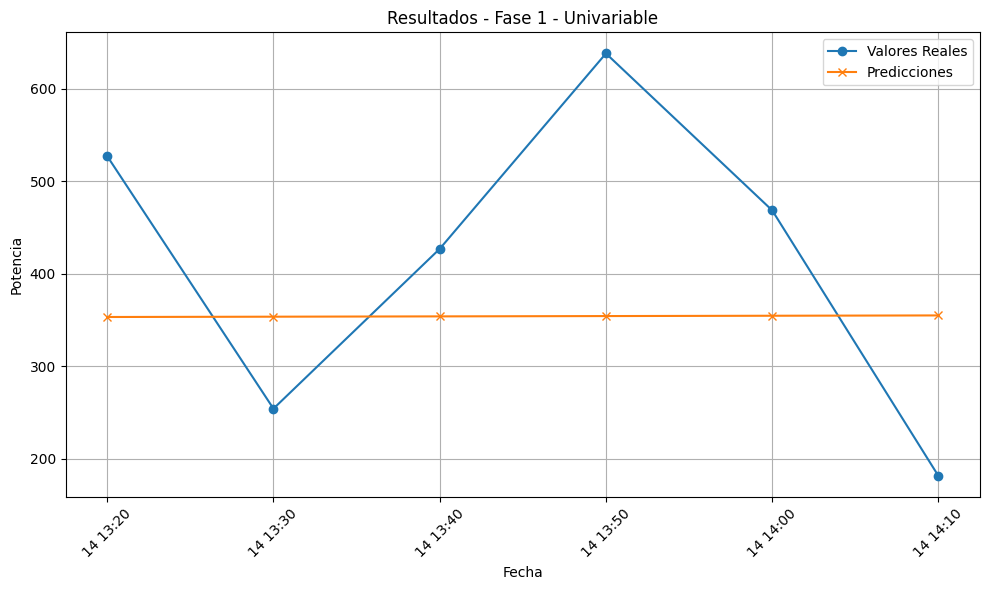

17:41:48 - cmdstanpy - INFO - Chain [1] start processing


🏃 View run prophet_phase_1_uni at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/5/runs/51561770a26f4fed8bd09532b66064d2
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/5


17:41:48 - cmdstanpy - INFO - Chain [1] done processing


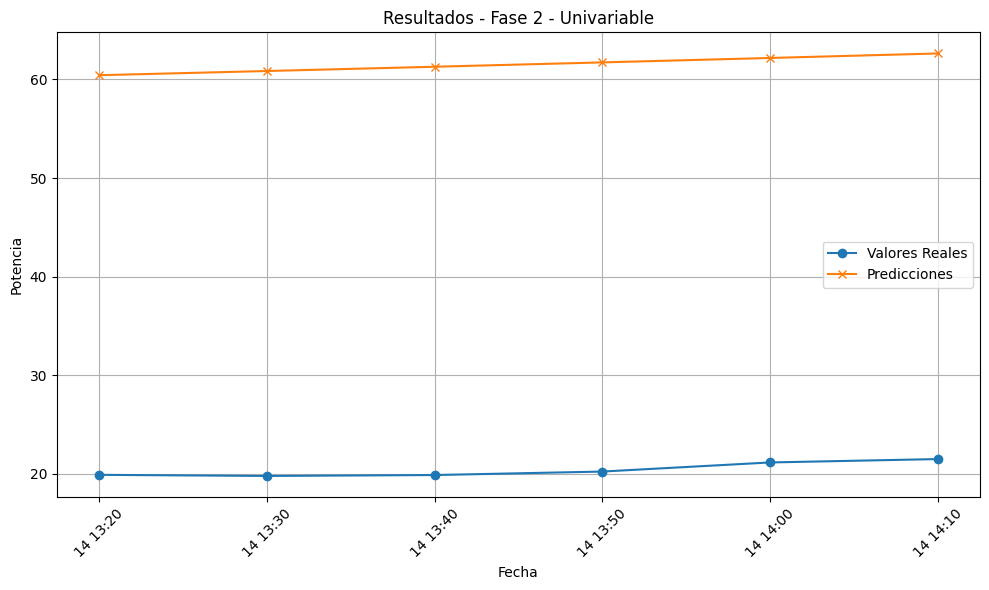

🏃 View run prophet_phase_2_uni at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/5/runs/15f0b0d57be7431fbebd3f67bd2476f2
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/5


17:41:50 - cmdstanpy - INFO - Chain [1] start processing
17:41:50 - cmdstanpy - INFO - Chain [1] done processing


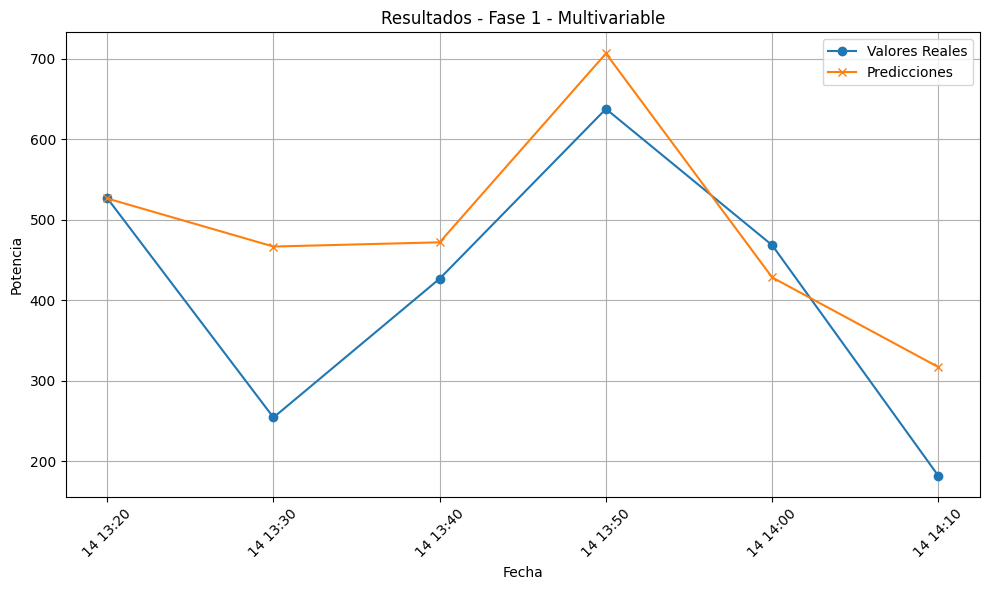

🏃 View run prophet_phase_1_multi at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/5/runs/74b6df6c1257415887b5638ec9fac583
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/5


17:41:51 - cmdstanpy - INFO - Chain [1] start processing
17:41:52 - cmdstanpy - INFO - Chain [1] done processing


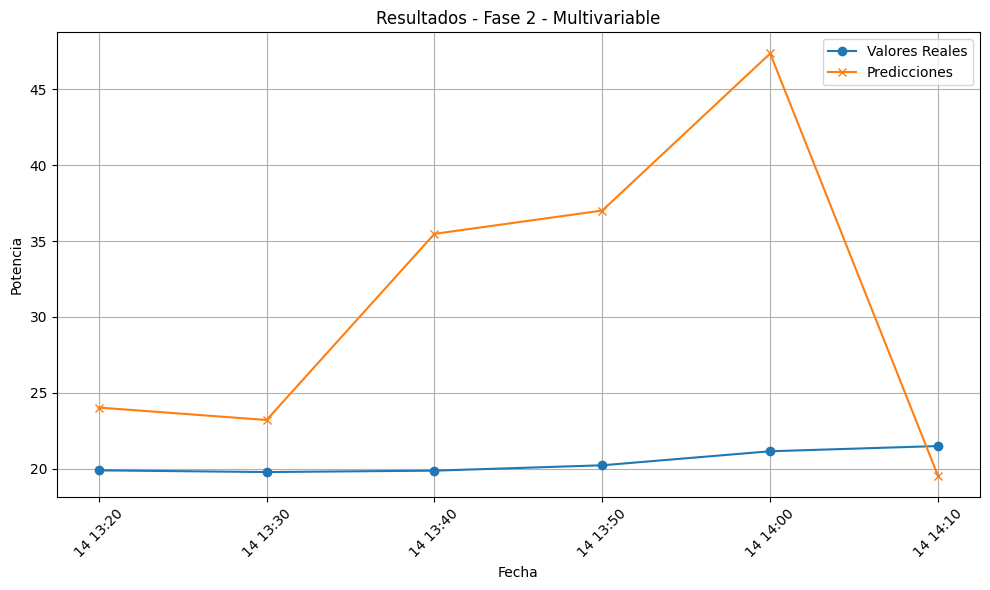

🏃 View run prophet_phase_2_multi at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/5/runs/485b5b2258cb499d86be9a46aa1a8368
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/5


,phase,variant,mae,rmse,mape,regressors
0,1,multivariable,83.747810,109.453496,31.354469,"Voltaje, FactorPotencia, Frecuencia"
1,1,univariable,152.810000,167.750924,42.225574,none
2,2,multivariable,11.349631,14.396703,55.405239,"Voltaje, FactorPotencia, Frecuencia"
3,2,univariable,41.109859,41.111044,201.634649,none


In [8]:
results = []

# 4 experimentos: 2 univariables + 2 multivariables
results.append(ejecutar_experimentos(1, False))
results.append(ejecutar_experimentos(2, False))
results.append(ejecutar_experimentos(1, True))
results.append(ejecutar_experimentos(2, True))

summary = pd.DataFrame(results).sort_values(['phase', 'variant']).reset_index(drop=True)
summary

In [9]:
print('Resumen de experimentos:')
display(summary)

best_rmse = summary.loc[summary['rmse'].idxmin()]
print(
    f"Mejor RMSE -> fase={int(best_rmse['phase'])}, variante={best_rmse['variant']}, rmse={best_rmse['rmse']:.4f}"
)
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

Resumen de experimentos:


,phase,variant,mae,rmse,mape,regressors
0,1,multivariable,83.747810,109.453496,31.354469,"Voltaje, FactorPotencia, Frecuencia"
1,1,univariable,152.810000,167.750924,42.225574,none
2,2,multivariable,11.349631,14.396703,55.405239,"Voltaje, FactorPotencia, Frecuencia"
3,2,univariable,41.109859,41.111044,201.634649,none


Mejor RMSE -> fase=2, variante=multivariable, rmse=14.3967
Tracking URI: http://vm-dev-docker-1.int.alephsub0.org:5000
